读取数据...
创建增强的台风特征...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_38796\4006945410.py:215: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_columns] = df[numeric_columns].applymap(lambda x: 0 if x < 0 else x)


创建基准数据集（不含台风特征）...
创建包含原始台风特征的数据集...
创建包含增强台风特征的数据集...
正在计算训练集与测试集实时指标...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_38796\4006945410.py:379: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(abs(tick))) for tick in current_ticks])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38796\4006945410.py:379: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(abs(tick))) for tick in current_ticks])


✓ 4x1 布局镜像对比图已保存至: results_v2/Figure1_mirror_comparison_4x1.png


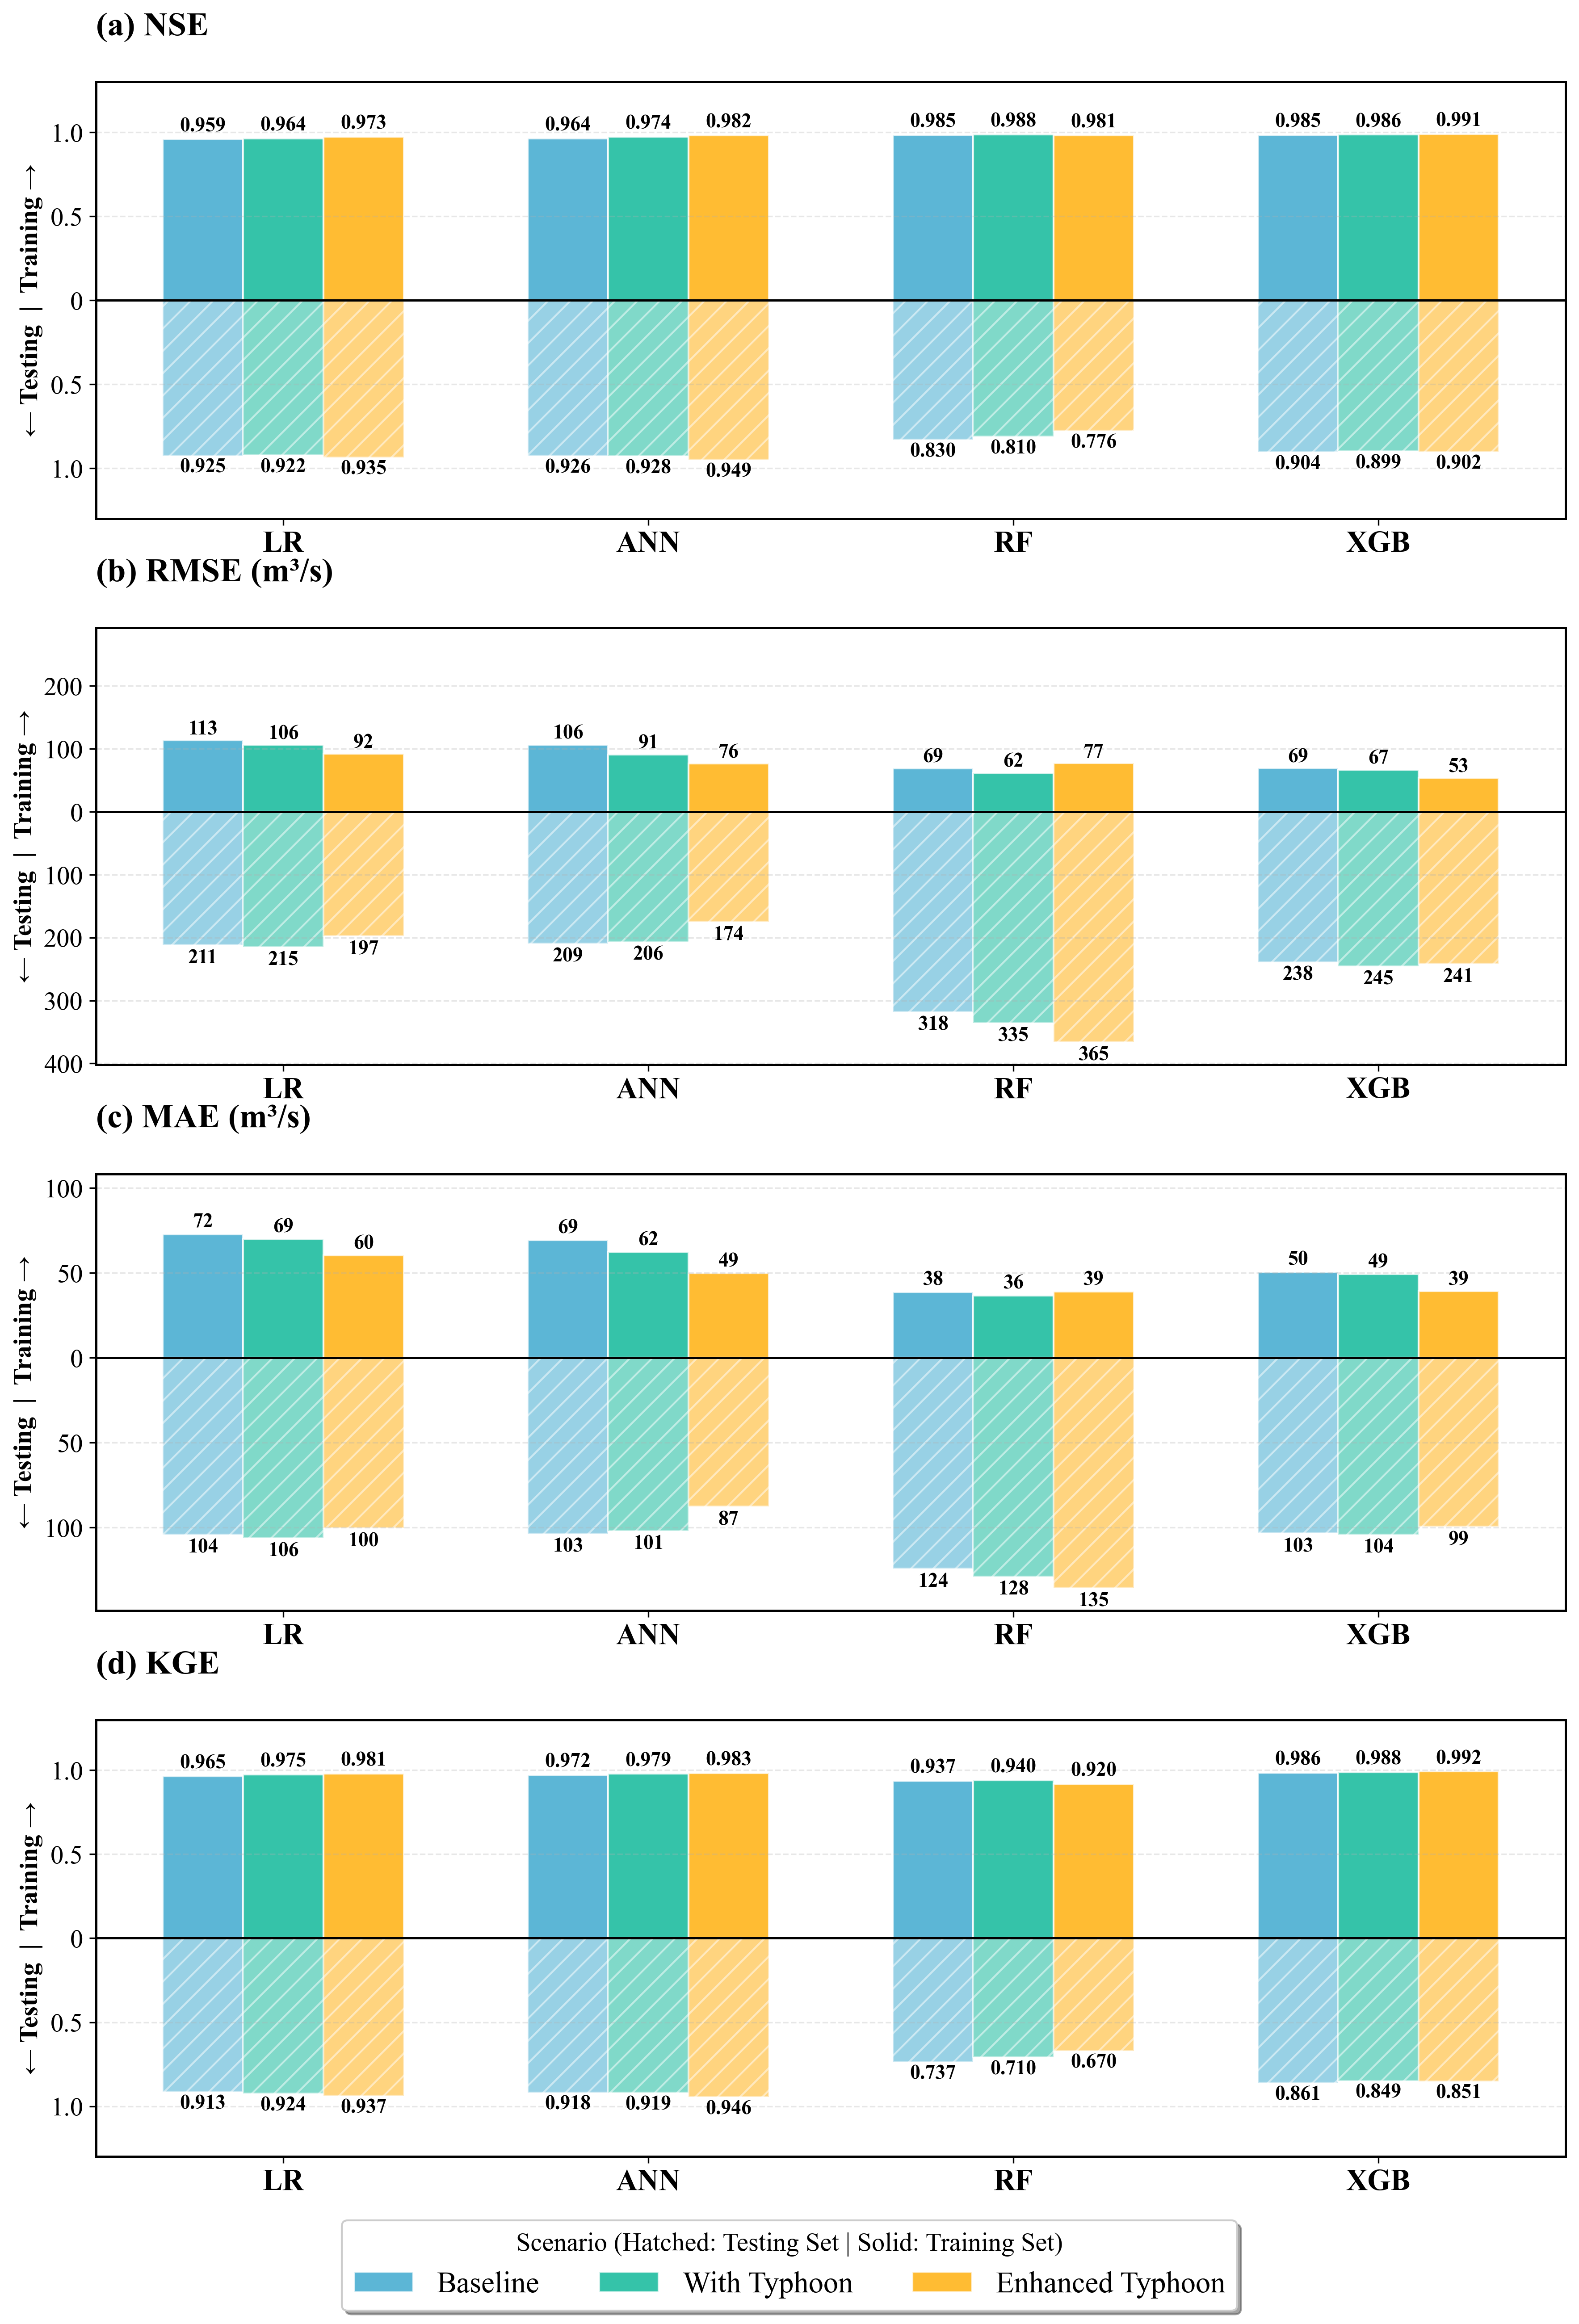

In [17]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ================== 1. 保留您的绘图配置 ==================
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["axes.linewidth"] = 1.2

def create_typhoon_features(df):
    """
    创建增强的台风特征
    """
    df = df.copy()
    
    # 1. 台风活跃标志（最基础的二值特征）
    df['台风活跃'] = (df['台风等级'] != 0).astype(int)
    
    # 2. 台风强度等级数值化
    def map_intensity(val):
        if pd.isna(val) or val == 0 or val == '0':
            return 0
        
        val_str = str(val).upper()
        
        if 'TD' in val_str or '热带低压' in val_str:
            return 1
        elif 'TS' in val_str or ('热带风暴' in val_str and '强' not in val_str):
            return 2
        elif 'STS' in val_str or '强热带风暴' in val_str:
            return 3
        elif 'STY' in val_str or '超强台风' in val_str:
            return 6
        elif 'TY' in val_str or ('台风' in val_str and '超强' not in val_str and '强' not in val_str):
            return 4
        elif '强台风' in val_str:
            return 5
        else:
            try:
                return float(val)
            except:
                return 0
    
    df['台风强度编码'] = df['台风强度'].apply(map_intensity)
    
    # 3. 台风距离影响权重（使用sigmoid函数进行非线性变换）
    # sigmoid函数将距离转换为0-1的影响权重
    # 距离250km时影响权重为0.5，距离越近权重越大
    df['台风距离影响'] = df.apply(
        lambda row: 1 / (1 + np.exp((row['距离博罗站'] - 250) / 50)) if row['距离博罗站'] > 0 else 0,
        axis=1
    )
    
    # 4. 台风综合影响指数（考虑风速、等级和距离的非线性综合影响）
    df['台风综合影响'] = df['风速'] * df['台风等级'] * df['台风距离影响']
    
    # 5. 台风风力等级（基于蒲福风级标准）
    def classify_wind(speed):
        if speed == 0:
            return 0
        elif speed < 17.2:
            return 1  # 热带低压
        elif speed < 24.5:
            return 2  # 热带风暴
        elif speed < 32.7:
            return 3  # 强热带风暴
        elif speed < 41.5:
            return 4  # 台风
        elif speed < 51.0:
            return 5  # 强台风
        else:
            return 6  # 超强台风
    
    df['风力等级'] = df['风速'].apply(classify_wind)
    
    # 6. 气压强度（标准化处理，相对于标准大气压的偏差）
    df['气压强度'] = df.apply(
        lambda row: (1013.25 - row['气压']) / 50 if row['气压'] > 0 else 0,
        axis=1
    )
    
    # 7. 台风持续时间特征
    df['台风持续天数'] = df['台风起始距今天数']
    
    # 8. 台风出现累积（滑动窗口 - 统计是否有台风）
    df['台风累积3天'] = df['台风活跃'].rolling(window=3, min_periods=1).sum()
    df['台风累积7天'] = df['台风活跃'].rolling(window=7, min_periods=1).sum()
    
    # 9. 台风影响强度累积（滑动窗口 - 统计台风影响强度的平均值）
    # 这个特征不仅看是否有台风，还考虑台风的实际影响强度
    df['台风强度累积3天'] = df['台风综合影响'].rolling(window=3, min_periods=1).mean()
    df['台风强度累积7天'] = df['台风综合影响'].rolling(window=7, min_periods=1).mean()
    
    # 10. 台风移动特征
    df['台风经度变化'] = df['台风经度'].diff().fillna(0)
    df['台风纬度变化'] = df['台风纬度'].diff().fillna(0)
    df['台风移动速度'] = np.sqrt(df['台风经度变化']**2 + df['台风纬度变化']**2)
    
    # 11. 台风相对位置特征（相对于博罗站的经纬度偏差）
    # 这样可以捕捉台风的方向信息
    boluo_lon = 114.2967
    boluo_lat = 23.15881
    df['台风相对经度'] = df['台风经度'] - boluo_lon
    df['台风相对纬度'] = df['台风纬度'] - boluo_lat
    
    # 12. 季节-台风交互特征
    df['date'] = pd.to_datetime(df['date'])
    df['月份'] = df['date'].dt.month
    df['是否台风季'] = df['月份'].isin([6, 7, 8, 9, 10]).astype(int)
    df['台风季节强度'] = df['台风综合影响'] * df['是否台风季']
    
    return df
    
def create_lagged_features(df, target_column, lag_days=7, feature_type='baseline'):
    """
    创建前 lag_days 天的特征用于预测目标列，使用(T-1)格式命名
    """
    features = []
    labels = []
    
    # 定义台风相关列
    typhoon_base_cols = ['台风起始距今天数', '台风经度', '台风纬度', 
                         '台风等级', '台风强度', '风速', '气压', '距离博罗站']
    typhoon_enhanced_cols = [
        '台风活跃',                # 台风活跃标志
        '台风强度编码',            # 强度数值化
        '台风距离影响',            # 改进：sigmoid距离影响（原来是'台风距离倒数'）
        '台风综合影响',            # 改进：综合影响指数（原来是'台风影响指数'）
        '风力等级',                # 风力等级分类（原来是'风速等级'）
        '气压强度',                # 改进：标准化气压（原来是'气压差'）
        '台风持续天数',            # 新增：持续时间
        '台风累积3天',             # 活跃累积
        '台风累积7天',             # 活跃累积
        '台风强度累积3天',         # 新增：强度累积
        '台风强度累积7天',         # 新增：强度累积
        '台风经度变化',            # 移动特征
        '台风纬度变化',            # 移动特征
        '台风移动速度',            # 移动特征
        '台风相对经度',            # 新增：相对位置
        '台风相对纬度',            # 新增：相对位置
        '月份',                    # 季节特征
        '是否台风季',              # 新增：台风季标志
        '台风季节强度'             # 新增：季节交互（原来是'台风季节交互'）
    ]
    
    # 根据特征类型选择列
    exclude_cols = ['date', target_column]
    
    if feature_type == 'baseline':
        # 基准模型：排除所有台风相关特征
        exclude_cols.extend(typhoon_base_cols)
        exclude_cols.extend(typhoon_enhanced_cols)
    elif feature_type == 'with_typhoon':
        # 包含原始台风特征，排除增强特征和台风强度原始列（因为有字符串）
        exclude_cols.extend(typhoon_enhanced_cols)
        exclude_cols.append('台风强度')  # 排除原始的台风强度列，使用编码后的
    elif feature_type == 'with_typhoon_enhanced':
        # 包含所有特征，但排除原始台风强度列
        exclude_cols.append('台风强度')  # 排除原始的台风强度列
    
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    for i in range(len(df) - lag_days):
        feature = df[feature_cols].iloc[i:i + lag_days].values.flatten()
        label = df[target_column].iloc[i + lag_days]
        features.append(feature)
        labels.append(label)
    
    # 生成特征列名（T-1, T-2, ..., T-7格式）
    feature_columns = []
    for day in range(1, lag_days + 1):
        for col in feature_cols:
            feature_columns.append(f'{col}(T-{day})')
    
    features = pd.DataFrame(features, columns=feature_columns)
    labels = pd.Series(labels, name=target_column)
    
    return features, labels
    
def prepare_data(data_file, lag_days=7):
    """
    准备三套数据：基准、包含原始台风特征、包含增强台风特征
    """
    # 读取数据
    print("读取数据...")
    df = pd.read_csv(data_file)
    
    # 数据预处理：将小于 0 的值填充为 0
    numeric_columns = df.select_dtypes(include=['number']).columns
    df[numeric_columns] = df[numeric_columns].applymap(lambda x: 0 if x < 0 else x)
    
    # 创建增强的台风特征
    print("创建增强的台风特征...")
    df_enhanced = create_typhoon_features(df)
    
    # 创建三套数据集
    print("创建基准数据集（不含台风特征）...")
    features_baseline, labels_baseline = create_lagged_features(
        df_enhanced, '博罗站流量', lag_days=lag_days, feature_type='baseline'
    )
    combined_baseline = pd.concat([features_baseline, labels_baseline], axis=1)
    combined_baseline['date'] = df_enhanced['date'][lag_days:].values
    
    print("创建包含原始台风特征的数据集...")
    features_typhoon, labels_typhoon = create_lagged_features(
        df_enhanced, '博罗站流量', lag_days=lag_days, feature_type='with_typhoon'
    )
    combined_typhoon = pd.concat([features_typhoon, labels_typhoon], axis=1)
    combined_typhoon['date'] = df_enhanced['date'][lag_days:].values
    
    print("创建包含增强台风特征的数据集...")
    features_enhanced, labels_enhanced = create_lagged_features(
        df_enhanced, '博罗站流量', lag_days=lag_days, feature_type='with_typhoon_enhanced'
    )
    combined_enhanced = pd.concat([features_enhanced, labels_enhanced], axis=1)
    combined_enhanced['date'] = df_enhanced['date'][lag_days:].values
    
    return combined_baseline, combined_typhoon, combined_enhanced

def split_data(combined_data, train_start='1985-01-01', train_end='2004-12-31',
               test_start='2005-01-01', test_end='2013-12-31'):
    """
    划分训练集和测试集
    """
    combined_data['date'] = pd.to_datetime(combined_data['date'])
    
    train_data = combined_data[
        (combined_data['date'] >= train_start) & 
        (combined_data['date'] <= train_end)
    ].copy()
    test_data = combined_data[
        (combined_data['date'] >= test_start) & 
        (combined_data['date'] <= test_end)
    ].copy()
    
    return train_data, test_data
    
# ================== 2. 核心评估函数 ==================
def calculate_metrics(y_true, y_pred):
    """实时计算水文评估指标"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    # NSE
    nse = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))
    
    # KGE
    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / np.std(y_true)
    beta = np.mean(y_pred) / np.mean(y_true)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    
    return {'NSE': nse, 'RMSE': rmse, 'MAE': mae, 'KGE': kge}

# ================== 3. 绘图主函数 ==================
# ================== 3. 修改后的绘图主函数 (4x1 布局) ==================
def plot_train_test_mirror_comparison(output_file='results_v2/Figure1_mirror_comparison_4x1.png'):
    # A. 重新准备数据与模型路径
    data_file = '../数据/typhoon_daily_boluo.csv'
    comb_base, comb_typ, comb_en = prepare_data(data_file, lag_days=7)
    
    scenarios = {
        'Baseline': {'data': split_data(comb_base), 'path': 'baseline'},
        'With Typhoon': {'data': split_data(comb_typ), 'path': 'with_typhoon'},
        'Enhanced Typhoon': {'data': split_data(comb_en), 'path': 'with_typhoon_enhanced'}
    }
    
    models = ['LR', 'ANN', 'RF', 'XGB']
    metrics_names = ['NSE', 'RMSE', 'MAE', 'KGE']
    colors = ['#33a4cc', '#02b494', '#ffab00'] 
    
    all_results = {}
    print("正在计算训练集与测试集实时指标...")
    for s_name, s_info in scenarios.items():
        all_results[s_name] = {}
        train_df, test_df = s_info['data']
        for m_name in models:
            m_path = f"models_v2/{s_info['path']}/{m_name}_best_model.pkl"
            model = joblib.load(m_path)
            
            X_train, y_train = train_df.drop(['博罗站流量', 'date'], axis=1), train_df['博罗站流量']
            X_test, y_test = test_df.drop(['博罗站流量', 'date'], axis=1), test_df['博罗站流量']
            
            all_results[s_name][m_name] = {
                'Train': calculate_metrics(y_train, model.predict(X_train)),
                'Test': calculate_metrics(y_test, model.predict(X_test))
            }

    # B. 开始镜像绘图 - 改为 4行1列
    # 增加高度 (24) 以确保每一行有足够的垂直空间显示标注
    fig, axes = plt.subplots(4, 1, figsize=(12, 18), dpi=300)
    x = np.arange(len(models))
    width = 0.22 

    for idx, metric in enumerate(metrics_names):
        ax = axes[idx] # 4x1 布局下，axes 直接用 idx 索引
        
        ax.axhline(0, color='black', linewidth=1.2)
        
        for i, (s_name, _) in enumerate(scenarios.items()):
            offset = (i - 1) * width
            train_vals = [all_results[s_name][m]['Train'][metric] for m in models]
            test_vals = [all_results[s_name][m]['Test'][metric] for m in models]
            test_vals_neg = [-v for v in test_vals]
            
            # 绘制柱子
            bars_t = ax.bar(x + offset, train_vals, width, label=s_name if idx==0 else "", 
                           color=colors[i], edgecolor='white', alpha=0.8)
            bars_v = ax.bar(x + offset, test_vals_neg, width, 
                           color=colors[i], edgecolor='white', alpha=0.5, hatch='//')

            # 添加数值标注
            for bar in bars_t:
                height = bar.get_height()
                # 增加 text 的 y 偏移量，防止紧贴柱子
                ax.text(bar.get_x() + bar.get_width()/2., height + (max(train_vals)*0.02),
                        f'{height:.3f}' if metric in ['NSE', 'KGE'] else f'{int(height)}',
                        ha='center', va='bottom', fontsize=11, fontweight='bold')
            
            for bar in bars_v:
                height = bar.get_height()
                label_val = abs(height)
                # 负方向偏移
                ax.text(bar.get_x() + bar.get_width()/2., height - (max(test_vals)*0.02),
                        f'{label_val:.3f}' if metric in ['NSE', 'KGE'] else f'{int(label_val)}',
                        ha='center', va='top', fontsize=11, fontweight='bold')

        # 细节美化
        if idx == 1 or idx == 2:
            ax.set_title(f'({chr(97+idx)}) {metric} (m³/s)', loc='left', fontweight='bold', 
                         pad=25, fontsize=18)
        else:
            ax.set_title(f'({chr(97+idx)}) {metric}', loc='left', fontweight='bold', pad=25, fontsize=18)
        
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontweight='bold', fontsize=16)
        
        # 统一 Y 轴标签
        ax.set_ylabel(f'← Testing  |  Training →', fontweight='bold', fontsize=14)

        if metric in ['NSE', 'KGE']:
            ax.set_ylim([-1.3, 1.3]) # 扩大范围防止数值标到框外
            ax.set_yticks([-1, -0.5, 0, 0.5, 1])
            ax.set_yticklabels(['1.0', '0.5', '0', '0.5', '1.0'])
        else:
            # 对于 RMSE/MAE，动态计算最大值并留出 30% 的空白给标注
            max_val = max([max([all_results[s][m]['Train'][metric], all_results[s][m]['Test'][metric]]) 
                          for s in scenarios for m in models])
            ax.set_ylim([-max_val*1.1, max_val*0.8])
            
            # 获取当前刻度并转为绝对值字符串
            current_ticks = ax.get_yticks()
            ax.set_yticklabels([str(int(abs(tick))) for tick in current_ticks])

        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # C. 布局调整
    # 增加子图间的垂直间距 (hspace)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.09, top=0.95, hspace=0.25) 

    # D. 图例
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), 
               ncol=3, frameon=True, shadow=True, fontsize=16,
               title='Scenario (Hatched: Testing Set | Solid: Training Set)')

    plt.savefig(output_file, bbox_inches='tight', pad_inches=0.3)
    print(f"✓ 4x1 布局镜像对比图已保存至: {output_file}")
    plt.show()

if __name__ == "__main__":
    plot_train_test_mirror_comparison()